In [1]:
import numpy as np
import pandas as pd

import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
import matplotlib.pyplot as plt



In [2]:
probe_counts = pd.read_csv('../../3_figure_FFPE/output/gift_probe_counts_per_cell.csv')[['name','BC2']]
probe_counts.columns = ['name','count_per_cell']

probe_counts = probe_counts.loc[probe_counts['name'] != 'EGFR VIII'] ## remove because this will not capture wt alleles

### get 0bp probes and subset to only genes targeted by 0bp probe
probe_counts['gene'] = probe_counts['name'].str.split(' ').str[0].str.replace('_0','')
control_probes = probe_counts.loc[probe_counts['name'].str.contains('0bp')]
probe_counts = probe_counts.loc[probe_counts['gene'].isin(control_probes['gene'])]

### get efficiencies
probe_counts['control_count_per_cell'] = probe_counts['gene'].map(control_probes.set_index('gene')['count_per_cell'].to_dict())
probe_counts['efficiency'] = probe_counts['count_per_cell'] / probe_counts['control_count_per_cell']
probe_counts = probe_counts.loc[~probe_counts['name'].str.contains('0bp')]

72
0.621463672314829


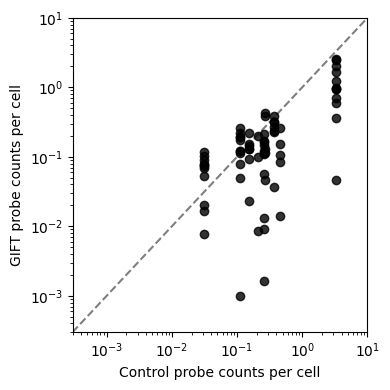

In [3]:
fig,ax = plt.subplots(figsize=(4,4))
ax.scatter(probe_counts['control_count_per_cell'], probe_counts['count_per_cell'], alpha=0.8, color = 'k')
ax.set_xscale('log')
ax.set_yscale('log')

ax.set_xlim(0.0003, 10)
ax.set_ylim(0.0003, 10)

ax.plot([0.0003, 10], [0.0003, 10], 'k--', alpha=0.5, label='y=x')

ax.set_xlabel('Control probe counts per cell')
ax.set_ylabel('GIFT probe counts per cell')

plt.tight_layout()

print(len(probe_counts))
print(probe_counts['efficiency'].median())
plt.savefig('../plots/gift_probe_efficiency_scatter.pdf')